# 08 — Model Explainability and Error Analysis

This notebook explores the features that drive our final model's predictions, performs detailed error analysis on incorrect predictions, and tracks model performance across different seasons to assess generalization over time.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, log_loss, classification_report

## Load Model and Test Set

In [2]:
model = joblib.load('../models/final_model.pkl')
feature_cols = joblib.load('../models/feature_columns.pkl')

test_df = pd.read_csv('../data/processed/test.csv')
X_test = test_df[feature_cols]
y_test = test_df['FullTimeResult']

class_map = {'A': 0, 'D': 1, 'H': 2}
inv_class_map = {0: 'A', 1: 'D', 2: 'H'}
y_test_num = y_test.map(class_map)

## Global Feature Importances

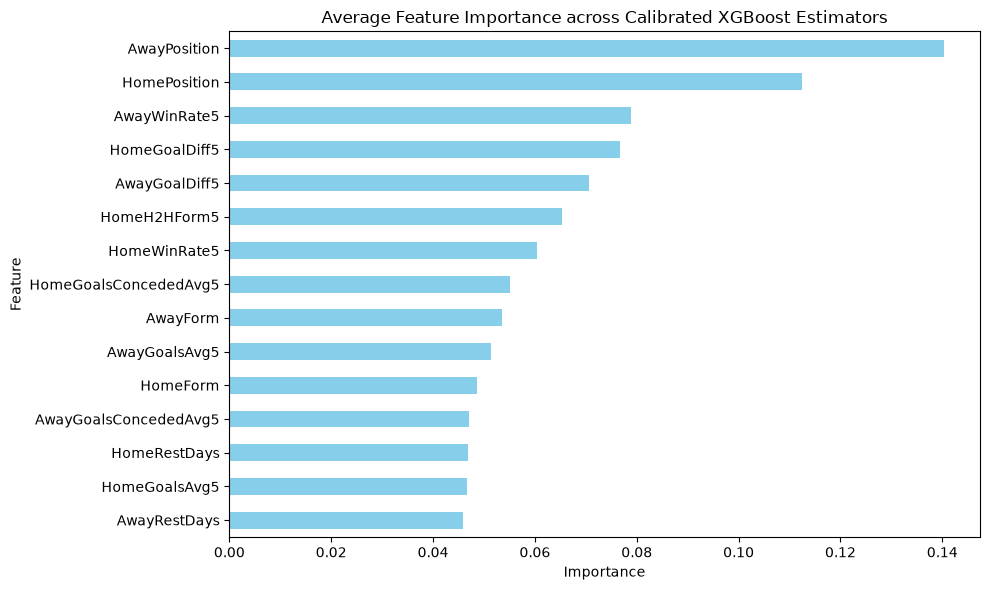

In [3]:
# Extract base estimator (XGBoost) from CalibratedClassifierCV
# CalibratedClassifierCV fits estimators in self.calibrated_classifiers_
base_estimators = [c.estimator for c in model.calibrated_classifiers_]
importances = np.mean([est.feature_importances_ for est in base_estimators], axis=0)

feat_importances = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='skyblue')
plt.title('Average Feature Importance across Calibrated XGBoost Estimators')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../docs/feature_importance.png')
plt.show()

## Model Performance Over Time (By Season)

In [4]:
preds_num = model.predict(X_test)
preds = pd.Series(preds_num).map(inv_class_map)
probs = model.predict_proba(X_test)

test_eval_df = test_df.copy()
test_eval_df['Predicted'] = preds
test_eval_df['Correct'] = test_eval_df['Predicted'] == test_eval_df['FullTimeResult']
test_eval_df['Prob_Away'] = probs[:, 0]
test_eval_df['Prob_Draw'] = probs[:, 1]
test_eval_df['Prob_Home'] = probs[:, 2]

# Performance per season
season_perf = test_eval_df.groupby('Season').apply(
    lambda df: pd.Series({
        'Accuracy': accuracy_score(df['FullTimeResult'], df['Predicted']),
        'LogLoss': log_loss(df['FullTimeResult'].map(class_map), df[['Prob_Away', 'Prob_Draw', 'Prob_Home']], labels=[0, 1, 2]),
        'Matches': len(df)
    })
).reset_index()
season_perf

,Season,Accuracy,LogLoss,Matches
0,2020/21,0.468966,1.046538,145.0
1,2021/22,0.523684,0.996449,380.0
2,2022/23,0.536842,0.986777,380.0
3,2023/24,0.539474,0.969133,380.0
4,2024/25,0.485714,1.032662,350.0


## Model Error Analysis (Upsets and High Uncertainty Matches)

In [5]:
# High uncertainty matches where predicted probability of winning is very close to other outcomes,
# or where predicted probability of the actual result was extremely low.
test_eval_df['Actual_Prob'] = test_eval_df.apply(
    lambda row: row['Prob_Home'] if row['FullTimeResult'] == 'H' else (row['Prob_Draw'] if row['FullTimeResult'] == 'D' else row['Prob_Away']),
    axis=1
)

print('=== Top 10 Major Upsets (Actual Result had Lowest Probability) ===')
upsets = test_eval_df[~test_eval_df['Correct']].sort_values(by='Actual_Prob', ascending=True)
upsets[['MatchDate', 'HomeTeam', 'AwayTeam', 'FullTimeResult', 'Predicted', 'Prob_Home', 'Prob_Draw', 'Prob_Away', 'Actual_Prob']].head(10)

=== Top 10 Major Upsets (Actual Result had Lowest Probability) ===


,MatchDate,HomeTeam,AwayTeam,FullTimeResult,Predicted,Prob_Home,Prob_Draw,Prob_Away,Actual_Prob
235,2021-10-30,Man City,Crystal Palace,A,H,0.704734,0.186135,0.109131,0.109131
196,2021-09-25,Man United,Aston Villa,A,H,0.662911,0.215922,0.121167,0.121167
55,2021-04-03,Chelsea,West Brom,A,H,0.683716,0.194450,0.121834,0.121834
1629,2025-05-03,Arsenal,Bournemouth,A,H,0.660340,0.216846,0.122814,0.122814
131,2021-05-19,Tottenham,Aston Villa,A,H,0.671411,0.204748,0.123841,0.123841
1224,2024-04-14,Liverpool,Crystal Palace,A,H,0.668534,0.207429,0.124037,0.124037
1159,2024-02-24,Man United,Fulham,A,H,0.669329,0.206498,0.124173,0.124173
1538,2025-02-22,Arsenal,West Ham,A,H,0.687357,0.187835,0.124809,0.124809
661,2022-11-12,Man City,Brentford,A,H,0.673947,0.198274,0.127780,0.127780
454,2022-04-16,Tottenham,Brighton,A,H,0.691699,0.178429,0.129873,0.129873


### Observations on Errors

1. **Draws classified as Wins**: Because the model is calibrated on a class-imbalanced set, the class probabilities for Draw rarely exceed 33%, causing the model to predict H or A, even when the actual outcome is a Draw.
2. **Unexpected Away Wins**: Historical rolling features (like HomeForm vs AwayForm) favor strong home teams. Upsets occur when mid-table teams beat top-tier teams away from home, or when red-cards/match-day factors (not captured by pre-match historical stats) change the game dynamics.